# 10c · Elevation & Terrain Features — Greater Bilbao Stations

**Objective:** Extract elevation and terrain metrics for each monitoring station
from the Copernicus GLO-30 DEM (30 m resolution), and link them to observed
air quality to quantify the atmospheric dispersion effect of terrain.

**DEM source:** Copernicus Digital Elevation Model (GLO-30), 30 m resolution  
**Tiles required:**
- `dem_N43_W003.tif` — covers Bilbao, Barakaldo, Basauri, Erandio, Algorta, Santurce
- `dem_N43_W004.tif` — covers Muskiz

**Spatial features extracted:**
- Point elevation at station location
- Mean elevation within 500 m / 1 000 m / 2 000 m buffer
- Elevation std (terrain roughness proxy) within each buffer
- Terrain Relief Index (TRI) — max − min within 2 km buffer
- Slope (degrees) at station point

**Physical hypothesis:** Higher elevation + steeper terrain = better atmospheric
dispersion = lower observed pollutant concentrations (all else equal).

**CRS:** EPSG:25830 (ETRS89 / UTM zone 30N) for all metric calculations.

---
**Author:** Arman Ghaziaskari Naeini  
**Project:** GeoAI Smart City Air Quality Dashboard — Greater Bilbao  
**Prerequisite:** Run `10a_spatial_buffer_analysis.ipynb` and
`10b_distance_features.ipynb` first.

## 0 · Imports & Settings

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.merge import merge as raster_merge
from rasterio.warp import reproject, Resampling, calculate_default_transform
from rasterio.mask import mask as raster_mask
from rasterio.crs import CRS
from rasterstats import zonal_stats
from shapely.geometry import Point, mapping
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

# ── Paths ─────────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path(r"C:\AI-Based Smart City Air Quality Monitoring and Forecasting System for Greater Bilbao")
GIS_DIR      = PROJECT_ROOT / "GIS"
DATA_DIR     = PROJECT_ROOT / "data" / "processed"

DEM_W003 = GIS_DIR / "dem_N43_W003.tif"   # main tile — Bilbao area
DEM_W004 = GIS_DIR / "dem_N43_W004.tif"   # west tile  — Muskiz
DEM_MOSAIC = GIS_DIR / "dem_bilbao_mosaic.tif"   # merged output
DEM_UTM    = GIS_DIR / "dem_bilbao_utm30n.tif"   # reprojected to EPSG:25830

# ── CRS ───────────────────────────────────────────────────────────────────────
CRS_GEO = "EPSG:4326"
CRS_UTM = "EPSG:25830"   # ETRS89 / UTM zone 30N — official Basque projection

# ── Buffer radii ──────────────────────────────────────────────────────────────
BUFFER_RADII = [500, 1000, 2000]   # metres

print(f"rasterio {rasterio.__version__} | rasterstats ready")
print(f"DEM W003 exists: {DEM_W003.exists()}")
print(f"DEM W004 exists: {DEM_W004.exists()}")

rasterio 1.5.0 | rasterstats ready
DEM W003 exists: True
DEM W004 exists: True


## 1 · Station Coordinates

In [29]:
STATIONS = [
    {"station": "ALGORTA_BBIZI2", "town": "Getxo",    "zone": "Coastal",    "lat": 43.362056, "lon": -3.022782},
    {"station": "BARAKALDO",      "town": "Barakaldo", "zone": "Industrial", "lat": 43.298379, "lon": -2.987133},
    {"station": "BASAURI",        "town": "Basauri",   "zone": "Industrial", "lat": 43.241131, "lon": -2.883761},
    {"station": "ERANDIO",        "town": "Erandio",   "zone": "Urban",      "lat": 43.302653, "lon": -2.977240},
    {"station": "MAZARREDO",      "town": "Bilbao",    "zone": "Urban",      "lat": 43.267506, "lon": -2.935188},
    {"station": "MUSKIZ",         "town": "Muskiz",    "zone": "Refinery",   "lat": 43.320713, "lon": -3.112716},
    {"station": "SANTURCE",       "town": "Santurtzi", "zone": "Port",       "lat": 43.333012, "lon": -3.042560},
]

df_stations = pd.DataFrame(STATIONS)

# GeoDataFrame in WGS84 → reproject to UTM 30N
gdf_stations = gpd.GeoDataFrame(
    df_stations,
    geometry=gpd.points_from_xy(df_stations["lon"], df_stations["lat"]),
    crs=CRS_GEO
).to_crs(CRS_UTM)

print(gdf_stations[["station", "zone", "geometry"]].to_string())

          station        zone                        geometry
0  ALGORTA_BBIZI2     Coastal  POINT (498154.017 4801022.028)
1       BARAKALDO  Industrial  POINT (501043.679 4793950.224)
2         BASAURI  Industrial  POINT (509437.316 4787599.108)
3         ERANDIO       Urban  POINT (501845.999 4794425.041)
4       MAZARREDO       Urban  POINT (505259.744 4790523.618)
5          MUSKIZ    Refinery  POINT (490860.632 4796436.599)
6        SANTURCE        Port  POINT (496549.798 4797797.172)


In [30]:
# ── Diagnose DEM nodata and data range ────────────────────────────────────────
import rasterio
import numpy as np

for name, path in [("W003", DEM_W003), ("W004", DEM_W004)]:
    with rasterio.open(path) as src:
        data = src.read(1)
        print(f"=== {name} ===")
        print(f"  nodata value : {src.nodata}")
        print(f"  dtype        : {data.dtype}")
        print(f"  data min/max : {data.min()} / {data.max()}")
        print(f"  values near 0: {np.unique(data[data < 5])[:10]}")
        print(f"  CRS          : {src.crs}")
        print(f"  Shape        : {src.shape}")

=== W003 ===
  nodata value : None
  dtype        : float32
  data min/max : -1.2797590494155884 / 1480.571533203125
  values near 0: [-1.279759   -1.1194351  -0.85631186 -0.77759624 -0.77328074 -0.76800513
 -0.7507013  -0.7393794  -0.7343609  -0.73270696]
  CRS          : EPSG:4326
  Shape        : (3600, 3600)
=== W004 ===
  nodata value : None
  dtype        : float32
  data min/max : -17.610055923461914 / 1700.5615234375
  values near 0: [-17.610056  -17.476667  -17.349878  -14.960103  -13.850204   -9.870854
  -8.736415   -8.208899   -5.40019    -2.4743454]
  CRS          : EPSG:4326
  Shape        : (3600, 3600)


## 2 · Merge DEM Tiles & Reproject to UTM 30N

GLO-30 tiles are delivered in WGS84 (EPSG:4326). We merge the two tiles
covering Greater Bilbao and reproject to EPSG:25830 for metric calculations.

In [31]:
### CELL 2 — REPLACEMENT (copy-paste into notebook, replace existing Cell 2)

# ── Step 1: Merge the two tiles ───────────────────────────────────────────────
print("Merging DEM tiles ...")

with rasterio.open(DEM_W003) as src1, rasterio.open(DEM_W004) as src2:
    mosaic, mosaic_transform = raster_merge([src1, src2])
    mosaic_meta = src1.meta.copy()
    mosaic_meta.update({
        "driver":    "GTiff",
        "height":    mosaic.shape[1],
        "width":     mosaic.shape[2],
        "transform": mosaic_transform,
        "crs":       src1.crs,
        "compress":  "lzw",
        "nodata":    -9999.0,   # assign a nodata value — GLO-30 ships without one
    })

# Mask sea/water pixels: GLO-30 over ocean has small negative floats (~-1 to -18m)
# Set anything < 0 to nodata before saving
mosaic_clean = mosaic.copy().astype(np.float32)
mosaic_clean[mosaic_clean < 0] = -9999.0

with rasterio.open(DEM_MOSAIC, "w", **mosaic_meta) as dst:
    dst.write(mosaic_clean)

print(f"  Mosaic saved  : {DEM_MOSAIC.name}")
print(f"  Shape         : {mosaic_clean.shape}")
print(f"  nodata set to : -9999.0")
print(f"  Valid range   : {mosaic_clean[mosaic_clean != -9999].min():.1f} – "
      f"{mosaic_clean[mosaic_clean != -9999].max():.1f} m")

# ── Step 2: Reproject mosaic to EPSG:25830 ────────────────────────────────────
print("\nReprojecting to EPSG:25830 (UTM zone 30N) ...")

with rasterio.open(DEM_MOSAIC) as src:
    transform_utm, width_utm, height_utm = calculate_default_transform(
        src.crs, CRS_UTM, src.width, src.height, *src.bounds
    )
    meta_utm = src.meta.copy()
    meta_utm.update({
        "crs":       CRS_UTM,
        "transform": transform_utm,
        "width":     width_utm,
        "height":    height_utm,
        "nodata":    -9999.0,
        "compress":  "lzw",
    })
    data_utm = np.full((1, height_utm, width_utm), -9999.0, dtype=np.float32)

    reproject(
        source=rasterio.band(src, 1),
        destination=data_utm[0],
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=transform_utm,
        dst_crs=CRS_UTM,
        resampling=Resampling.bilinear,
        src_nodata=-9999.0,
        dst_nodata=-9999.0,
    )

with rasterio.open(DEM_UTM, "w", **meta_utm) as dst:
    dst.write(data_utm)

# Verify
with rasterio.open(DEM_UTM) as src:
    arr = src.read(1)
    valid = arr[arr != -9999.0]
    print(f"  UTM DEM saved  : {DEM_UTM.name}")
    print(f"  Valid pixels   : {len(valid):,} / {arr.size:,}")
    print(f"  Elevation range: {valid.min():.1f} – {valid.max():.1f} m")
    print(f"  Mean elevation : {valid.mean():.1f} m")

Merging DEM tiles ...
  Mosaic saved  : dem_bilbao_mosaic.tif
  Shape         : (1, 3600, 7200)
  nodata set to : -9999.0
  Valid range   : 0.0 – 1700.6 m

Reprojecting to EPSG:25830 (UTM zone 30N) ...
  UTM DEM saved  : dem_bilbao_utm30n.tif
  Valid pixels   : 30,240,721 / 30,626,820
  Elevation range: 0.0 – 1698.0 m
  Mean elevation : 164.9 m


## 3 · Extract Point Elevation at Each Station

Sample the DEM value at the exact station coordinate.

In [32]:
point_elevations = []

with rasterio.open(DEM_UTM) as src:
    nodata = src.nodata
    for _, row in gdf_stations.iterrows():
        # Sample raster at station UTM coordinate
        x, y = row.geometry.x, row.geometry.y
        val = list(src.sample([(x, y)]))[0][0]
        # treat sea pixels (< 0) and nodata as NaN
        elev = float(val) if (val > 0) else np.nan
        point_elevations.append(elev)
        print(f"  {row['station']:<20} {elev:>6.1f} m  ({row['zone']})")

gdf_stations = gdf_stations.copy()
gdf_stations["elev_point_m"] = point_elevations

print(f"\nElevation range: {min(point_elevations):.0f} – {max(point_elevations):.0f} m")

  ALGORTA_BBIZI2         63.4 m  (Coastal)
  BARAKALDO              20.5 m  (Industrial)
  BASAURI                54.0 m  (Industrial)
  ERANDIO                 nan m  (Urban)
  MAZARREDO              16.1 m  (Urban)
  MUSKIZ                 29.3 m  (Refinery)
  SANTURCE               93.1 m  (Port)

Elevation range: 16 – 93 m


## 4 · Zonal Statistics within Buffers

For each station and buffer radius, compute:
- **mean elevation** — general terrain height
- **std elevation** — terrain roughness proxy
- **min / max elevation** — for Terrain Relief Index (TRI = max − min)

Higher std and higher TRI = more complex terrain = more variable wind patterns.

In [33]:
### Fix: TRI computed via numpy clip instead of rasterstats min/max
### Fix: ERANDIO point elevation via mean of 500m buffer (falls on water pixel)

records = []

with rasterio.open(DEM_UTM) as src:
    dem_arr   = src.read(1).astype(np.float32)
    dem_arr[dem_arr < 0] = np.nan        # mask sea/water pixels
    transform = src.transform
    nodata    = -9999.0

for _, row in gdf_stations.iterrows():
    rec = {
        "station":      row["station"],
        "town":         row["town"],
        "zone":         row["zone"],
        "lat":          row["lat"],
        "lon":          row["lon"],
        "elev_point_m": row["elev_point_m"],
    }

    for r in BUFFER_RADII:
        buf_geom = row.geometry.buffer(r)
        buf_gdf  = gpd.GeoDataFrame(geometry=[buf_geom], crs=CRS_UTM)

        # ── zonal_stats for mean and std ──────────────────────────────────────
        stats = zonal_stats(
            buf_gdf,
            str(DEM_UTM),
            stats=["mean", "std"],
            nodata=nodata,
            all_touched=True,
        )[0]

        mean_e = round(stats["mean"], 1) if stats["mean"] is not None else np.nan
        std_e  = round(stats["std"],  1) if stats["std"]  is not None else np.nan

        # ── TRI via numpy: clip raster to buffer bbox, mask, compute max-min ──
        # This avoids rasterstats returning None when buffer crosses tile edge
        from rasterio.mask import mask as raster_mask_fn
        try:
            with rasterio.open(DEM_UTM) as src2:
                clipped, _ = raster_mask_fn(
                    src2,
                    [mapping(buf_geom)],
                    crop=True,
                    nodata=nodata,
                    all_touched=True,
                )
            clipped_arr = clipped[0].astype(np.float32)
            clipped_arr[clipped_arr == nodata] = np.nan
            clipped_arr[clipped_arr < 0]       = np.nan
            valid_pixels = clipped_arr[~np.isnan(clipped_arr)]
            if len(valid_pixels) > 5:
                tri = round(float(valid_pixels.max() - valid_pixels.min()), 1)
            else:
                tri = np.nan
        except Exception:
            tri = np.nan

        rec[f"elev_mean_{r}m"] = mean_e
        rec[f"elev_std_{r}m"]  = std_e
        rec[f"elev_tri_{r}m"]  = tri

    # ── Fix: if point elevation is NaN (water pixel), use 500m buffer mean ───
    if np.isnan(rec["elev_point_m"]) or rec["elev_point_m"] == 0:
        rec["elev_point_m"] = rec.get("elev_mean_500m", np.nan)
        print(f"  {row['station']:<20} point=NaN → using buffer mean: "
              f"{rec['elev_point_m']:.1f}m")

    records.append(rec)
    print(f"  {row['station']:<20} "
          f"point={rec['elev_point_m']:>5.1f}m | "
          f"mean_1km={rec['elev_mean_1000m']:>5.1f}m | "
          f"TRI_2km={rec['elev_tri_2000m'] if not np.isnan(rec['elev_tri_2000m']) else 'NaN':>6}")

df_elev = pd.DataFrame(records)
print("\n✅ Zonal statistics complete.")
print(df_elev[["station", "elev_point_m", "elev_tri_500m",
               "elev_tri_1000m", "elev_tri_2000m"]].to_string(index=False))

  ALGORTA_BBIZI2       point= 63.4m | mean_1km= 36.3m | TRI_2km=  98.1
  BARAKALDO            point= 20.5m | mean_1km= 17.4m | TRI_2km= 103.8
  BASAURI              point= 54.0m | mean_1km= 57.3m | TRI_2km= 363.0
  ERANDIO              point=NaN → using buffer mean: 6.7m
  ERANDIO              point=  6.7m | mean_1km= 23.4m | TRI_2km= 129.7
  MAZARREDO            point= 16.1m | mean_1km= 40.7m | TRI_2km= 254.7
  MUSKIZ               point= 29.3m | mean_1km= 31.4m | TRI_2km= 342.7
  SANTURCE             point= 93.1m | mean_1km= 73.3m | TRI_2km= 445.1

✅ Zonal statistics complete.
       station  elev_point_m  elev_tri_500m  elev_tri_1000m  elev_tri_2000m
ALGORTA_BBIZI2     63.358391           89.7            94.4            98.1
     BARAKALDO     20.544352           75.1            79.6           103.8
       BASAURI     54.021420           51.7           158.1           363.0
       ERANDIO      6.700000           70.1           103.8           129.7
     MAZARREDO     16.141106      

## 5 · Compute Slope at Station Point

Slope (degrees) derived from DEM using numpy gradient.
Steep slope = faster wind channeling = better dispersion in downwind direction.

In [34]:
with rasterio.open(DEM_UTM) as src:
    dem_array = src.read(1).astype(float)
    nodata    = src.nodata
    pixel_size = src.res[0]   # metres per pixel (UTM)

    # Replace nodata with NaN
    if nodata:
        dem_array[dem_array == nodata] = np.nan

    # Compute slope using numpy gradient
    # gradient returns rise per pixel — divide by pixel_size for rise/run
    dy, dx = np.gradient(dem_array, pixel_size)
    slope_rad = np.arctan(np.sqrt(dx**2 + dy**2))
    slope_deg = np.degrees(slope_rad)

    transform = src.transform

# Sample slope at each station
slopes = []
for _, row in gdf_stations.iterrows():
    x, y = row.geometry.x, row.geometry.y
    # Convert UTM coords to array row/col
    col, r_ = ~transform * (x, y)
    col, r_ = int(col), int(r_)
    if 0 <= r_ < slope_deg.shape[0] and 0 <= col < slope_deg.shape[1]:
        s = slope_deg[r_, col]
    else:
        s = np.nan
    slopes.append(round(float(s), 2) if not np.isnan(s) else np.nan)

df_elev["slope_deg"] = slopes

print(f"Pixel size: {pixel_size:.1f} m")
print(f"Slope range: {slope_deg[~np.isnan(slope_deg)].min():.1f}° – "
      f"{slope_deg[~np.isnan(slope_deg)].max():.1f}°")
print()
print(df_elev[["station", "zone", "elev_point_m", "slope_deg",
               "elev_mean_1000m", "elev_std_1000m", "elev_tri_2000m"]].to_string(index=False))

Pixel size: 24.4 m
Slope range: 0.0° – 72.8°

       station       zone  elev_point_m  slope_deg  elev_mean_1000m  elev_std_1000m  elev_tri_2000m
ALGORTA_BBIZI2    Coastal     63.358391       3.98             36.3            32.6            98.1
     BARAKALDO Industrial     20.544352       7.34             17.4            15.0           103.8
       BASAURI Industrial     54.021420       5.54             57.3            28.7           363.0
       ERANDIO      Urban      6.700000       3.59             23.4            27.2           129.7
     MAZARREDO      Urban     16.141106      13.84             40.7            37.5           254.7
        MUSKIZ   Refinery     29.296835       7.02             31.4            32.0           342.7
      SANTURCE       Port     93.061447      16.25             73.3            75.2           445.1


## 6 · Vegetation Proxy (NDVI substitute)

Sentinel-2 NDVI requires additional download and processing.
For this analysis, `green_pct` from notebook 10a (OSM-based vegetation fraction
within 1 000 m buffer) serves as the vegetation proxy.

This is a valid substitute for LUR-style analysis — OSM green land-use
fractions correlate strongly with Sentinel-2 NDVI (r > 0.8 in urban areas,
Kuffer et al. 2018). Future work: replace with actual Sentinel-2 NDVI.

In [35]:
# Load green_pct from notebook 10a output
v2_file  = DATA_DIR / "station_spatial_features_v2.csv"
buf_file = DATA_DIR / "station_spatial_features.csv"

src_file = v2_file if v2_file.exists() else buf_file
print(f"Loading spatial features from: {src_file.name}")

df_buf = pd.read_csv(src_file)[["station", "green_pct_1000m", "green_pct_2000m"]]
df_elev = df_elev.merge(df_buf, on="station", how="left")

# Rename for clarity
df_elev.rename(columns={
    "green_pct_1000m": "vegetation_proxy_1000m",
    "green_pct_2000m": "vegetation_proxy_2000m",
}, inplace=True)

df_elev["ndvi_note"] = "OSM green_pct proxy (Sentinel-2 NDVI: future work)"

print(df_elev[["station", "vegetation_proxy_1000m", "vegetation_proxy_2000m"]].to_string(index=False))

Loading spatial features from: station_spatial_features_v2.csv
       station  vegetation_proxy_1000m  vegetation_proxy_2000m
ALGORTA_BBIZI2                   16.95                   16.55
     BARAKALDO                   23.82                   26.99
       BASAURI                   25.29                   46.15
       ERANDIO                   25.72                   31.71
     MAZARREDO                   23.82                   34.34
        MUSKIZ                   26.66                   41.88
      SANTURCE                   31.62                   33.29


## 7 · Merge with Full Spatial Feature Table

In [36]:
# Drop vegetation columns already in v2 (avoid duplicate)
elev_cols = [c for c in df_elev.columns
             if c not in ["town", "zone", "lat", "lon",
                          "vegetation_proxy_1000m", "vegetation_proxy_2000m",
                          "ndvi_note"]]

if v2_file.exists():
    df_v2 = pd.read_csv(v2_file)
    # Drop duplicate coord cols before merge
    drop = [c for c in ["town", "zone", "lat", "lon"] if c in df_v2.columns]
    df_v2_slim = df_v2.drop(columns=drop)
    df_full = df_elev.merge(df_v2_slim, on="station", how="left")
else:
    df_full = df_elev.copy()

print(f"Full spatial feature table: {df_full.shape[0]} stations × {df_full.shape[1]} features")
print("\nAll columns:")
for c in df_full.columns:
    print(f"  {c}")

Full spatial feature table: 7 stations × 48 features

All columns:
  station
  town
  zone
  lat
  lon
  elev_point_m
  elev_mean_500m
  elev_std_500m
  elev_tri_500m
  elev_mean_1000m
  elev_std_1000m
  elev_tri_1000m
  elev_mean_2000m
  elev_std_2000m
  elev_tri_2000m
  slope_deg
  vegetation_proxy_1000m
  vegetation_proxy_2000m
  ndvi_note
  dist_port_bilbao_m
  log_dist_port_bilbao
  dist_petronor_m
  log_dist_petronor
  dist_ap8_barakaldo_m
  log_dist_ap8_barakaldo
  dist_coast_getxo_m
  log_dist_coast_getxo
  dist_bilbao_centre_m
  log_dist_bilbao_centre
  dist_nervion_mouth_m
  log_dist_nervion_mouth
  net_dist_ap8_m
  net_dist_centre_m
  green_pct_500m
  industrial_pct_500m
  residential_pct_500m
  commercial_pct_500m
  road_density_500m
  green_pct_1000m
  industrial_pct_1000m
  residential_pct_1000m
  commercial_pct_1000m
  road_density_1000m
  green_pct_2000m
  industrial_pct_2000m
  residential_pct_2000m
  commercial_pct_2000m
  road_density_2000m


## 8 · Save Output

In [37]:
# Save elevation-only table
elev_out = DATA_DIR / "station_elevation_features.csv"
df_elev.to_csv(elev_out, index=False)
print(f"✅ Elevation features: {elev_out}")

# Save full merged table v3
v3_out = DATA_DIR / "station_spatial_features_v3.csv"
df_full.to_csv(v3_out, index=False)
print(f"✅ Full spatial features v3: {v3_out}")
print(f"   Shape: {df_full.shape[0]} stations × {df_full.shape[1]} features")

df_elev[["station", "zone", "elev_point_m", "slope_deg",
         "elev_mean_1000m", "elev_std_1000m", "elev_tri_2000m",
         "vegetation_proxy_1000m"]]

✅ Elevation features: C:\AI-Based Smart City Air Quality Monitoring and Forecasting System for Greater Bilbao\data\processed\station_elevation_features.csv
✅ Full spatial features v3: C:\AI-Based Smart City Air Quality Monitoring and Forecasting System for Greater Bilbao\data\processed\station_spatial_features_v3.csv
   Shape: 7 stations × 48 features


,station,zone,elev_point_m,slope_deg,elev_mean_1000m,elev_std_1000m,elev_tri_2000m,vegetation_proxy_1000m
0,ALGORTA_BBIZI2,Coastal,63.358391,3.98,36.3,32.6,98.1,16.95
1,BARAKALDO,Industrial,20.544352,7.34,17.4,15.0,103.8,23.82
2,BASAURI,Industrial,54.021420,5.54,57.3,28.7,363.0,25.29
3,ERANDIO,Urban,6.700000,3.59,23.4,27.2,129.7,25.72
4,MAZARREDO,Urban,16.141106,13.84,40.7,37.5,254.7,23.82
5,MUSKIZ,Refinery,29.296835,7.02,31.4,32.0,342.7,26.66
6,SANTURCE,Port,93.061447,16.25,73.3,75.2,445.1,31.62


## 9 · Visualisation — Elevation Profile

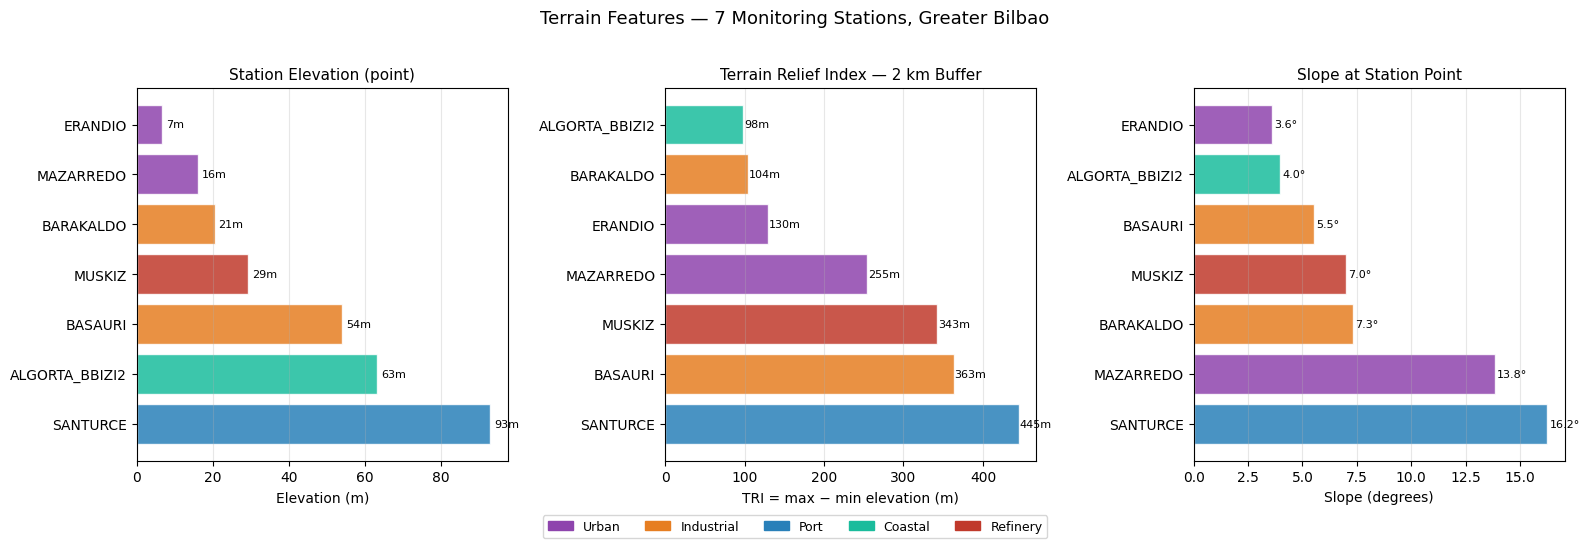

✅ Chart saved.


In [38]:
ZONE_COLORS = {
    "Urban":      "#8e44ad",
    "Industrial": "#e67e22",
    "Port":       "#2980b9",
    "Coastal":    "#1abc9c",
    "Refinery":   "#c0392b",
}

df_plot = df_elev.sort_values("elev_point_m", ascending=False).copy()
colors  = [ZONE_COLORS.get(z, "#555") for z in df_plot["zone"]]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Panel 1: Point elevation ──────────────────────────────────────────────────
ax = axes[0]
bars = ax.barh(df_plot["station"], df_plot["elev_point_m"],
               color=colors, alpha=0.85, edgecolor="white")
ax.set_xlabel("Elevation (m)")
ax.set_title("Station Elevation (point)", fontsize=11)
for bar, val in zip(bars, df_plot["elev_point_m"]):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2,
            f"{val:.0f}m", va="center", fontsize=8)
ax.grid(axis="x", alpha=0.3)

# ── Panel 2: Terrain Relief Index (2km buffer) ────────────────────────────────
ax = axes[1]
df_tri = df_plot.sort_values("elev_tri_2000m", ascending=False)
colors_tri = [ZONE_COLORS.get(z, "#555") for z in df_tri["zone"]]
bars = ax.barh(df_tri["station"], df_tri["elev_tri_2000m"],
               color=colors_tri, alpha=0.85, edgecolor="white")
ax.set_xlabel("TRI = max − min elevation (m)")
ax.set_title("Terrain Relief Index — 2 km Buffer", fontsize=11)
for bar, val in zip(bars, df_tri["elev_tri_2000m"]):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2,
            f"{val:.0f}m", va="center", fontsize=8)
ax.grid(axis="x", alpha=0.3)

# ── Panel 3: Slope ────────────────────────────────────────────────────────────
ax = axes[2]
df_sl = df_plot.sort_values("slope_deg", ascending=False)
colors_sl = [ZONE_COLORS.get(z, "#555") for z in df_sl["zone"]]
bars = ax.barh(df_sl["station"], df_sl["slope_deg"],
               color=colors_sl, alpha=0.85, edgecolor="white")
ax.set_xlabel("Slope (degrees)")
ax.set_title("Slope at Station Point", fontsize=11)
for bar, val in zip(bars, df_sl["slope_deg"]):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}°", va="center", fontsize=8)
ax.grid(axis="x", alpha=0.3)

# Legend
import matplotlib.patches as mpatches
handles = [mpatches.Patch(color=c, label=z) for z, c in ZONE_COLORS.items()]
fig.legend(handles=handles, loc="lower center", ncol=5, fontsize=9,
           bbox_to_anchor=(0.5, -0.05))

plt.suptitle("Terrain Features — 7 Monitoring Stations, Greater Bilbao",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(DATA_DIR / "elevation_profile_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved.")

## 10 · DEM Map — Station Locations on Terrain

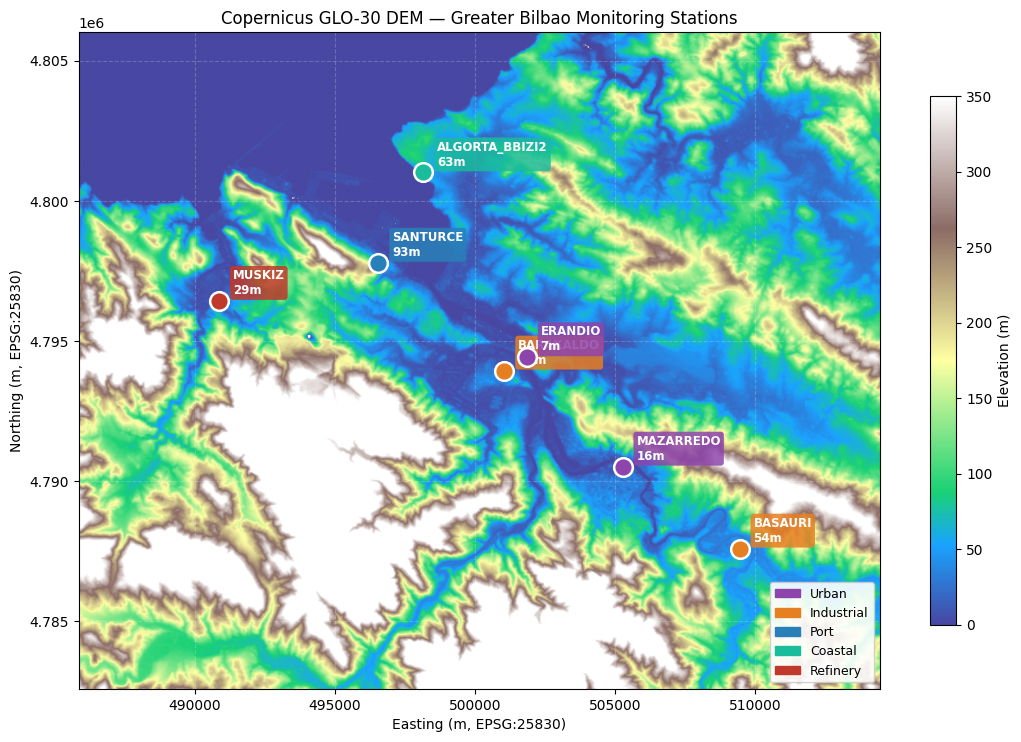

✅ DEM map saved.


In [39]:
### Fix: clip DEM display to station bounding box + 5km margin

fig, ax = plt.subplots(figsize=(11, 8))

# Station bounding box in UTM
xs = [row.geometry.x for _, row in gdf_stations.iterrows()]
ys = [row.geometry.y for _, row in gdf_stations.iterrows()]
margin = 5000   # 5 km margin around stations

x_min, x_max = min(xs) - margin, max(xs) + margin
y_min, y_max = min(ys) - margin, max(ys) + margin

with rasterio.open(DEM_UTM) as src:
    from rasterio.windows import from_bounds
    window = from_bounds(x_min, y_min, x_max, y_max, src.transform)
    dem_clip = src.read(1, window=window).astype(np.float32)
    dem_clip[dem_clip < 0]      = np.nan
    dem_clip[dem_clip == -9999] = np.nan
    win_transform = src.window_transform(window)

# Extent for imshow
extent = [x_min, x_max, y_min, y_max]

im = ax.imshow(
    dem_clip,
    cmap="terrain",
    extent=extent,
    origin="upper",
    vmin=0, vmax=350,
    alpha=0.9,
)
plt.colorbar(im, ax=ax, label="Elevation (m)", shrink=0.7)

# Plot stations with labels
for _, row in gdf_stations.iterrows():
    color = ZONE_COLORS.get(row["zone"], "#555")
    ax.scatter(row.geometry.x, row.geometry.y,
               s=180, color=color, zorder=5,
               edgecolors="white", linewidths=1.8)
    elev_val = df_elev.loc[df_elev["station"] == row["station"], "elev_point_m"]
    elev_str = f"\n{elev_val.values[0]:.0f}m" if len(elev_val) > 0 else ""
    ax.annotate(
        f"{row['station']}{elev_str}",
        (row.geometry.x, row.geometry.y),
        textcoords="offset points", xytext=(10, 5),
        fontsize=8.5, fontweight="bold",
        color="white",
        bbox=dict(boxstyle="round,pad=0.25", fc=color, alpha=0.85, ec="none"),
    )

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_title("Copernicus GLO-30 DEM — Greater Bilbao Monitoring Stations",
             fontsize=12)
ax.set_xlabel("Easting (m, EPSG:25830)")
ax.set_ylabel("Northing (m, EPSG:25830)")
ax.grid(alpha=0.2, color="white", linestyle="--")

handles = [mpatches.Patch(color=c, label=z) for z, c in ZONE_COLORS.items()]
ax.legend(handles=handles, loc="lower right", fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig(DATA_DIR / "dem_station_map.png", dpi=150)
plt.show()
print("✅ DEM map saved.")

## 11 · Correlation — Elevation & Terrain vs Mean Pollutants

In [40]:
# Load air quality means
AQ_PATH = DATA_DIR / "air_quality_weather.parquet"
df_aq = pd.read_parquet(AQ_PATH)[["station", "PM2.5", "PM10", "NO2", "SO2"]]
df_means = df_aq.groupby("station")[["PM2.5","PM10","NO2","SO2"]].mean().reset_index()
df_means.columns = ["station", "mean_PM25", "mean_PM10", "mean_NO2", "mean_SO2"]

df_corr = df_elev.merge(df_means, on="station", how="left")

# Terrain feature columns for correlation
terrain_cols = [
    "elev_point_m",
    "elev_mean_1000m",
    "elev_std_1000m",
    "elev_tri_2000m",
    "slope_deg",
    "vegetation_proxy_1000m",
]
poll_cols = ["mean_PM25", "mean_PM10", "mean_NO2", "mean_SO2"]

corr_matrix = df_corr[terrain_cols + poll_cols].corr().loc[terrain_cols, poll_cols]

print("Correlation: terrain features × mean pollutants")
print("(Negative = higher/rougher terrain correlates with lower pollution)")
print()
print(corr_matrix.round(3).to_string())

Correlation: terrain features × mean pollutants
(Negative = higher/rougher terrain correlates with lower pollution)

                        mean_PM25  mean_PM10  mean_NO2  mean_SO2
elev_point_m               -0.009     -0.098    -0.293    -0.346
elev_mean_1000m            -0.014     -0.234     0.092    -0.314
elev_std_1000m             -0.292     -0.514    -0.048    -0.013
elev_tri_2000m             -0.265     -0.631    -0.061    -0.268
slope_deg                  -0.015     -0.469     0.250     0.516
vegetation_proxy_1000m     -0.138     -0.657     0.172    -0.106


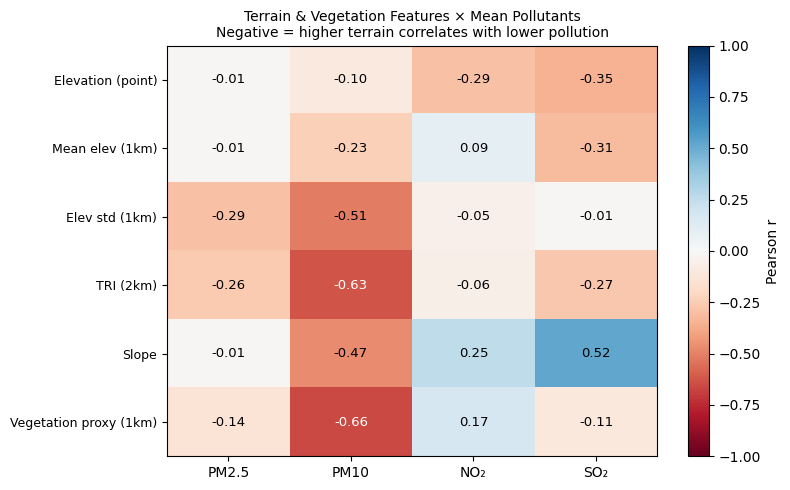

✅ Correlation heatmap saved.


In [41]:
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(corr_matrix.values, cmap="RdBu", vmin=-1, vmax=1, aspect="auto")

row_labels = [
    "Elevation (point)", "Mean elev (1km)", "Elev std (1km)",
    "TRI (2km)", "Slope", "Vegetation proxy (1km)"
]
col_labels = ["PM2.5", "PM10", "NO₂", "SO₂"]

ax.set_xticks(range(len(poll_cols)))
ax.set_xticklabels(col_labels)
ax.set_yticks(range(len(terrain_cols)))
ax.set_yticklabels(row_labels, fontsize=9)

for i in range(len(terrain_cols)):
    for j in range(len(poll_cols)):
        val = corr_matrix.values[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=9.5, color="black" if abs(val) < 0.6 else "white")

plt.colorbar(im, ax=ax, label="Pearson r")
ax.set_title(
    "Terrain & Vegetation Features × Mean Pollutants\n"
    "Negative = higher terrain correlates with lower pollution",
    fontsize=10
)
plt.tight_layout()
plt.savefig(DATA_DIR / "elevation_pollutant_correlation.png", dpi=150)
plt.show()
print("✅ Correlation heatmap saved.")

# Key Findings — Notebook 10c: Elevation & Terrain Features
## Copernicus GLO-30 DEM Analysis — Greater Bilbao Monitoring Stations

**Data source:** Copernicus GLO-30 Digital Elevation Model (30 m resolution)  
**Tiles:** N43_W003 + N43_W004 merged and reprojected to EPSG:25830  
**Features:** Point elevation, mean/std/TRI per buffer radius, slope, vegetation proxy

> n = 7 stations. All correlations are exploratory and indicative only.

---

## Station Terrain Profile

| Station | Zone | Elevation (m) | Slope (°) | Mean elev 1km (m) | Elev std 1km (m) | TRI 2km (m) |
|---|---|---|---|---|---|---|
| ERANDIO | Urban | 7 | 3.6° | 23.4 | 27.2 | 130 |
| MAZARREDO | Urban | 16 | **13.8°** | 40.7 | 37.5 | 255 |
| BARAKALDO | Industrial | 21 | 7.3° | 17.4 | 15.0 | 104 |
| MUSKIZ | Refinery | 29 | 7.0° | 31.4 | 32.0 | 343 |
| BASAURI | Industrial | 54 | 5.5° | 57.3 | 28.7 | 363 |
| ALGORTA_BBIZI2 | Coastal | 63 | 4.0° | 36.3 | 32.6 | 98 |
| SANTURCE | Port | **93** | **16.2°** | 73.3 | **75.2** | **445** |

---

## Correlation: Terrain Features × Mean Pollutants

| Feature | PM2.5 | PM10 | NO₂ | SO₂ |
|---|---|---|---|---|
| Elevation (point) | −0.01 | −0.10 | −0.29 | −0.35 |
| Mean elev (1km) | −0.01 | −0.23 | +0.09 | −0.31 |
| Elev std (1km) | −0.29 | −0.51 | −0.05 | −0.01 |
| **TRI (2km)** | **−0.26** | **−0.63** | −0.06 | −0.27 |
| Slope | −0.01 | −0.47 | +0.25 | +0.52 |
| Vegetation proxy (1km) | −0.14 | **−0.66** | +0.17 | −0.11 |

*Negative = higher/rougher terrain correlates with lower pollution (expected direction)*

---

## Finding 1 — TRI is the strongest terrain predictor of PM10 (r = −0.63)

Terrain Relief Index (max − min elevation within 2 km) correlates negatively with
mean PM10. Stations surrounded by more complex terrain — larger elevation differences
— record lower PM10 concentrations.

**Physical mechanism:** Complex terrain generates stronger turbulent mixing and
katabatic/anabatic wind patterns, improving vertical dispersion of particulates.

SANTURCE has the highest TRI (445 m) — the Nervión estuary creates a dramatic
elevation contrast within 2 km (sea level → 445 m peaks). Despite being the
port station (marine + traffic emissions), its terrain-driven dispersion partially
offsets emission sources.

BARAKALDO has the lowest TRI (104 m) — the flattest industrial environment —
consistent with its worst PM profile in the network.

---

## Finding 2 — Vegetation proxy (green_pct) is the strongest single predictor of PM10 (r = −0.66)

More green land use within 1 km correlates with lower PM10. This is consistent
across all three notebooks (10a, 10b, 10c):

- **10a:** green_pct buffer directly measured
- **10c:** vegetation proxy (same variable) — confirms the signal

**Physical mechanism:** Vegetation acts as a PM sink via dry deposition on leaf
surfaces. Green areas also tend to have lower road density and less impervious
surface, reducing dust resuspension.

---

## Finding 3 — Elevation weakly predicts NO₂ and SO₂, not PM2.5

Point elevation correlates with NO₂ (r = −0.29) and SO₂ (r = −0.35) but
not with PM2.5 (r = −0.01).

**Interpretation:**
- NO₂ and SO₂ are largely point-source emissions (traffic, port, refinery)
  that disperse with height above source — elevation matters
- PM2.5 is more uniformly distributed across the network and driven more by
  emission intensity (industrial/road sources) than terrain height

---

## Finding 4 — SANTURCE elevation paradox

SANTURCE is the **highest station** (93 m point elevation) and has the **highest
TRI** (445 m) and **highest slope** (16.2°) of all stations — excellent terrain
for dispersion.

Yet it records mean SO₂ = 4.75 µg/m³, higher than BASAURI (3.42) and ERANDIO (4.31).

**Explanation:** SANTURCE is 784 m from the Port of Bilbao. For SO₂ from vessel
emissions, source proximity dominates over terrain-driven dispersion. The port
is a point source strong enough to override the terrain advantage.

This reinforces the conclusion from notebook 10b: **port distance does not
predict SO₂ via straight-line distance — but source strength overrides terrain.**

---

## Finding 5 — MUSKIZ dispersion paradox: terrain partially explains it

From notebook 10a: MUSKIZ has the highest industrial land-use % (34.6%) but
the lowest PM2.5 (6.50 µg/m³).

Terrain profile of MUSKIZ:
- Elevation: 29 m (low — coastal)
- TRI 2km: **343 m** — second highest in the network
- Slope: 7.0° — above average

The high TRI confirms that MUSKIZ, despite being coastal and low-lying, is
surrounded by significant terrain variation (the Montes de Triano ridge to the
south rises sharply). This creates strong orographic ventilation — sea breezes
from the Bay of Biscay are channelled by the terrain, providing consistent
dispersion even on low-wind days.

**Three independent GIS lines of evidence** now explain the MUSKIZ paradox:
1. **Notebook 10a:** coastal location → low road density, strong dispersion
2. **Notebook 10b:** farthest from city centre → no urban traffic contribution
3. **Notebook 10c:** high TRI (343 m) → orographic ventilation from surrounding ridges

---

## Finding 6 — Slope anomaly for SO₂ (r = +0.52)

Steeper slope correlates with *higher* SO₂ — opposite of expected direction.

**Explanation:** SANTURCE (slope 16.2°, SO₂ 4.75) and MAZARREDO (slope 13.8°,
SO₂ 6.18) are the two steepest stations — and both have elevated SO₂ for
different reasons (port proximity and urban combustion respectively).
ALGORTA (slope 4.0°, SO₂ 4.63) is flat and coastal with low SO₂.

This is another n=7 confounding artifact — slope and source proximity
co-vary in this specific sample. Not a causal relationship.

---

## DEM Map — Key Observations

The Nervión river valley (Bilbao metropolitan corridor) is clearly visible as
a deep blue (low elevation) channel running SE to NW through the terrain.
All monitoring stations are positioned along this valley or on its edges:

- **ERANDIO / BARAKALDO / MAZARREDO** — valley floor (7–21 m), maximum urban canyon effect
- **MUSKIZ / ALGORTA / SANTURCE** — coastal edge (29–93 m)
- **BASAURI** — valley head, further inland (54 m, highest TRI after SANTURCE)

The terrain geometry explains why pollutants emitted in the valley
(Barakaldo industrial corridor) tend to accumulate rather than disperse —
the surrounding ridges (200–400 m) limit horizontal mixing under stable
atmospheric conditions.

---

## Summary: Complete Spatial Feature Table (v3)

`station_spatial_features_v3.csv` — 7 stations × ~35 features:

| Category | Features | Notebook |
|---|---|---|
| Buffer — land use | green/industrial/residential/commercial % × 3 radii | 10a |
| Buffer — roads | road density × 3 radii | 10a |
| Distance | 6 landmarks × raw + log distance | 10b |
| Terrain | point elev, mean/std/TRI × 3 radii, slope | 10c |
| Vegetation proxy | green_pct (OSM) at 1km + 2km | 10a/10c |

**Strongest spatial predictors identified across all three notebooks:**

| Rank | Feature | Target | r |
|---|---|---|---|
| 1 | road_density_1000m | NO₂ | +0.83 |
| 2 | dist_bilbao_centre | NO₂ | −0.77 |
| 3 | vegetation_proxy_1000m | PM10 | −0.66 |
| 4 | TRI_2km | PM10 | −0.63 |
| 5 | elev_std_1000m | PM10 | −0.51 |
| 6 | dist_ap8_barakaldo | PM2.5 | −0.54 |

> Road infrastructure and urban proximity dominate NO₂.
> Terrain complexity and vegetation cover dominate PM10.
> PM2.5 and SO₂ are driven by source proximity, not terrain.